Setup

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

path= '/Users/user/Dev/ml/w4/diabetes/'
db12_full= path+'diabetes_012_health_indicators_BRFSS2015.csv'
db5050_binar= path+'diabetes_binary_5050split_health_indicators_BRFSS2015.csv'
db12_binar= path+'diabetes_binary_health_indicators_BRFSS2015.csv'

df_full_012=pd.read_csv(db12_full)
df_5050_01=pd.read_csv(db5050_binar)
df_full_01=pd.read_csv(db12_binar)

# Graphics style
sns.set_theme(palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 12})
LABELS = {0: 'without diabetes', 1: 'Diabetes'}
COLORS = {0: '#66BB6A', 1: '#FF0000'}

Data Frames structure

In [2]:
df_full_012.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [3]:
df_full_01.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [4]:
df_5050_01.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,...,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,0.500000,0.563458,0.525703,0.975259,29.856985,0.475273,0.062171,0.147810,0.703036,0.611795,...,0.954960,0.093914,2.837082,3.752037,5.810417,0.252730,0.456997,8.584055,4.920953,5.698311
std,0.500004,0.495960,0.499342,0.155336,7.113954,0.499392,0.241468,0.354914,0.456924,0.487345,...,0.207394,0.291712,1.113565,8.155627,10.062261,0.434581,0.498151,2.852153,1.029081,2.175196
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000
50%,0.500000,1.000000,1.000000,1.000000,29.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000
75%,1.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,1.000000,11.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


Data analysis

Correlation between targets and all the variables

In [5]:
def corr_comp(dataframes: dict, targets: dict, method='spearman'):
    '''
        Compare correlations from several DataFrames against their own target.
        Parameters:
            dataframes: dict  {'name': DataFrame}
            targets: dict  {'name': 'target_column'}
            method: str   'spearman' (default) or 'pearson'
    '''
    corr_res= {}
    for name, df in dataframes.items():
        target= targets[name]
        corr= df.corr(method= method, numeric_only=True)[target].drop(target).to_frame(name=name)
        corr_res[name]= corr

    # Unir en una sola tabla por variables (índice común)
    corr_tbl = pd.concat(corr_res.values(), axis=1)
    corr_tbl.columns = [f'{name}\n({targets[name]})' for name in corr_res]
    corr_tbl = corr_tbl.sort_values(by=corr_tbl.columns[0], ascending=True)

    return corr_tbl

dataframes= {'df_12': df_full_012, 'df5050': df_5050_01, 'df_binar': df_full_01}
targets= {'df_12': 'Diabetes_012', 'df5050': 'Diabetes_binary', 'df_binar': 'Diabetes_binary'}
correlation= corr_comp(dataframes, targets)
display(correlation)

,df_12\n(Diabetes_012),df5050\n(Diabetes_binary),df_binar\n(Diabetes_binary)
Income,-0.172611,-0.232529,-0.163305
Education,-0.126862,-0.169926,-0.120038
PhysActivity,-0.121988,-0.158666,-0.118133
Veggies,-0.059353,-0.079293,-0.056584
HvyAlcoholConsump,-0.057244,-0.094853,-0.057056
Fruits,-0.042268,-0.054077,-0.040779
AnyHealthcare,0.014530,0.023191,0.016255
Sex,0.030143,0.044413,0.031430
NoDocbcCost,0.037379,0.040977,0.031433
MentHlth,0.044921,0.056515,0.040049


Possible training data (5050 Data Frame)

In [6]:
df_5050_copy = df_5050_01.copy()
print(f'Dimensions: {df_5050_copy.shape[0]:,} rows × {df_5050_copy.shape[1]} columns')
print(f'\nNull Values per column:',end='')
nulls = df_5050_copy.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else ' No null values')
print(f'\n Data type:')
print(df_5050_copy.dtypes)

Dimensions: 70,692 rows × 22 columns

Null Values per column: No null values

 Data type:
Diabetes_binary         float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object


In [7]:
# df_full_012.hist(bins=15, figsize=(14, 12), edgecolor="red")
# df_full_01.hist(bins=15, figsize=(14, 12), edgecolor="green")
# df_5050_01.hist(bins=15, figsize=(14, 12), edgecolor="blue")
# plt.tight_layout()
# plt.show()

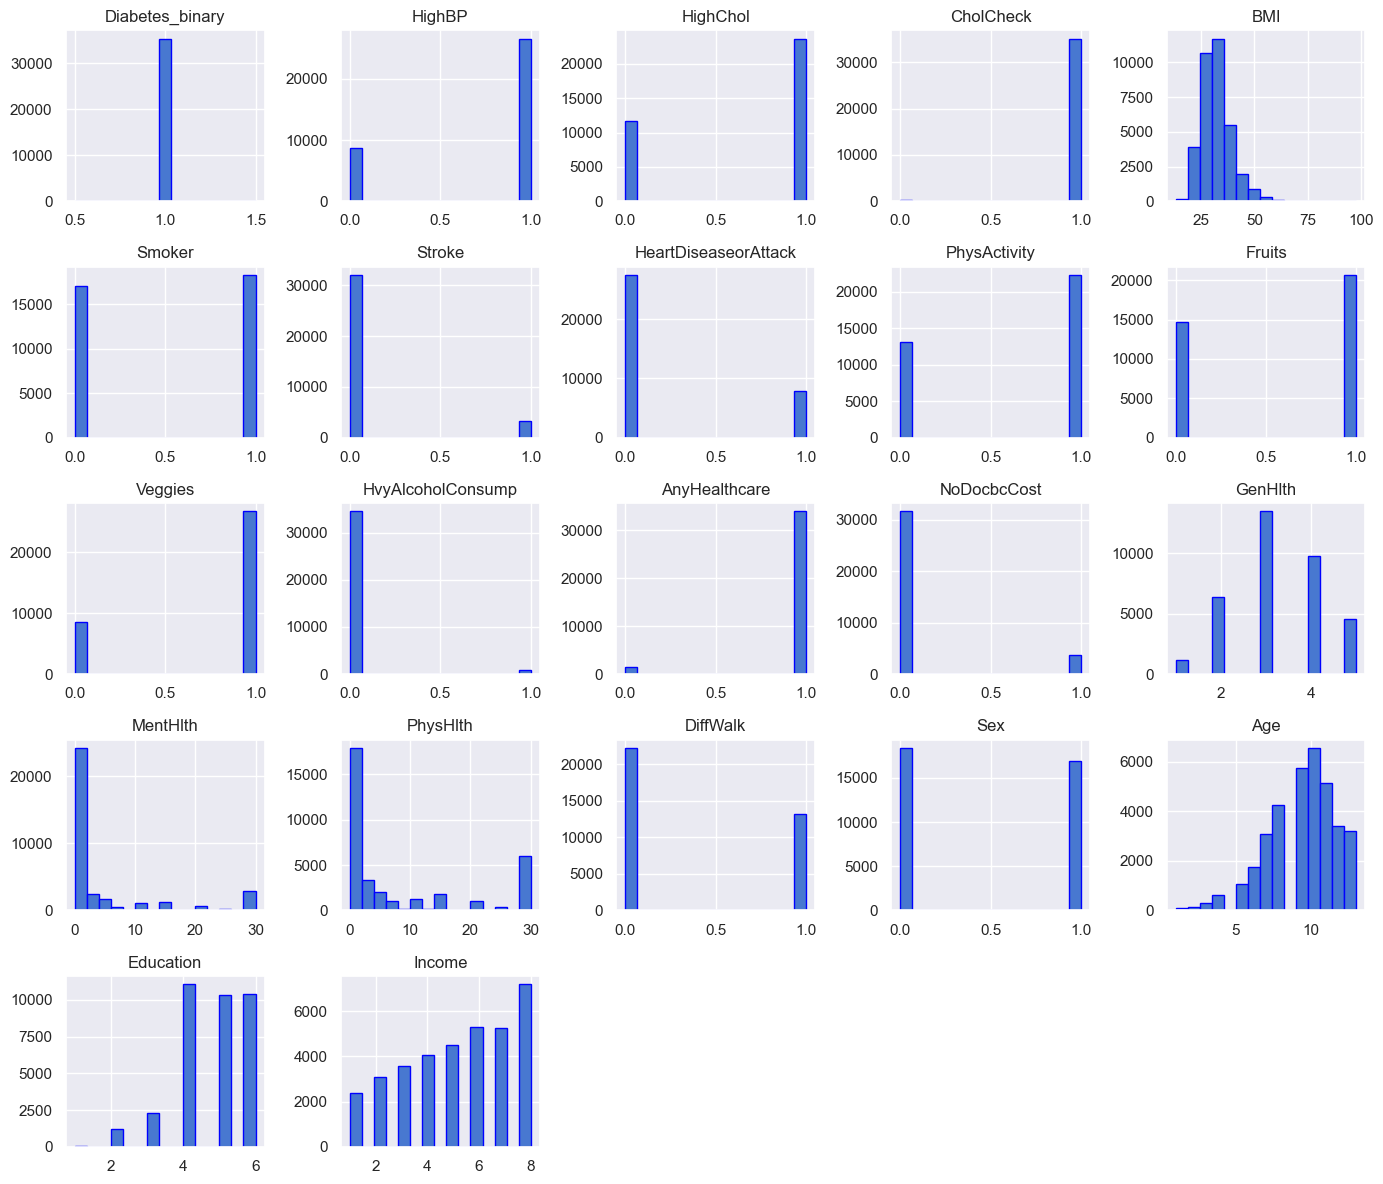

In [8]:
df_5050_01_gesund= df_5050_01[df_5050_01['Diabetes_binary']==0]
df_5050_01_krank = df_5050_01[df_5050_01['Diabetes_binary']== 1]
# numeric_cols= ['BMI', 'Age', 'GenHlth', 'MentHlth', 'PhysHlth', 'HighBP']
# comparision= pd.DataFrame({
#     'Gesund': gesund[numeric_cols].mean(),
#     'Krank': krank[numeric_cols].mean(),
#     'Diff_%': ((krank[numeric_cols].mean()- gesund[numeric_cols].mean())/gesund[numeric_cols].mean()
df_5050_01_krank.hist(bins=15, figsize=(14, 12), edgecolor="blue")
plt.tight_layout()
plt.show()



In [9]:
# corr_gesund = df_5050_01_gesund.corr()
# corr_krank  = df_5050_01_krank.corr()
# df_5050_01_krank.hist(bins=15, figsize=(14, 12), edgecolor="blue")
# plt.tight_layout()
# plt.show()

In [10]:
# '''Ahmad Code for 3D graphics'''
# fig = plt.figure(figsize=(14, 6))
#
# ax1 = fig.add_subplot(1, 2, 1, projection='3d')
# sc1 = ax1.scatter(
# GenHlth, MentHlth, Sex,
# c=Education,
# cmap='viridis',
# s=20
# )
# ax1.set_xlabel('GenHlth')
# ax1.set_ylabel('MentHlth')
# ax1.set_zlabel('Sex')
# ax1.set_title('3D Plot')
# fig.colorbar(sc1, ax=ax1, label='Education')
#
# ax2 = fig.add_subplot(1, 2, 2, projection='3d')
# sc2 = ax2.scatter(
# HighBP,MentHlth, BMI,
# c=Age,
# cmap='viridis',
# s=20
# )
# ax2.set_xlabel('HighBP')
# ax2.set_ylabel('MentHlth')
# ax2.set_zlabel('BMI')
# ax2.set_title('3D Plot ')
# fig.colorbar(sc2, ax=ax2, label='Age')
#
# plt.tight_layout()
# plt.show()

Spearman correlation (rho) between each variable and Diabetes status

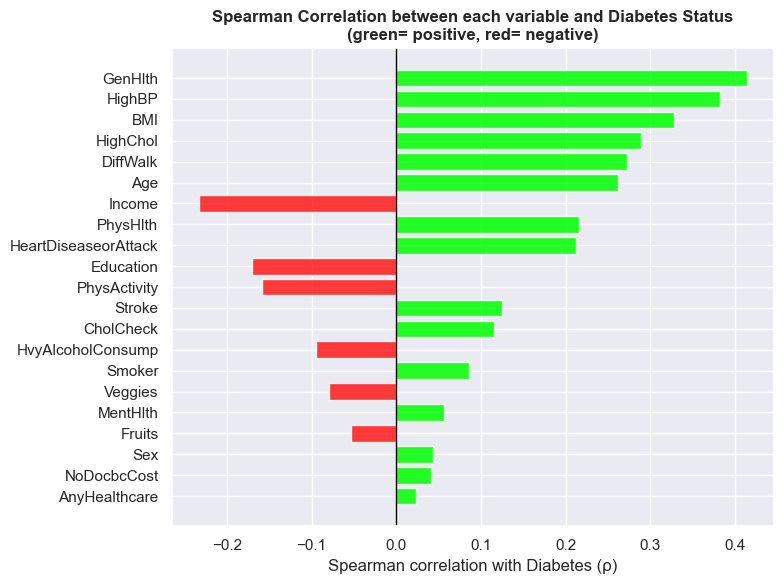


 Top 10 variables correlated with Diabetes_binary:
            Variable      ρ  p-value
             GenHlth  0.414      0.0
              HighBP  0.382      0.0
                 BMI  0.328      0.0
            HighChol  0.289      0.0
            DiffWalk  0.273      0.0
                 Age  0.262      0.0
              Income -0.233      0.0
            PhysHlth  0.216      0.0
HeartDiseaseorAttack  0.212      0.0
           Education -0.170      0.0


In [11]:
# Spearman correlation (ρ optimal for ordinal and binary variables without normal distribution)
corr_results = []
cols_to_test = [c for c in df_5050_copy.columns if c != 'Diabetes_binary']  #list with all variables but 'Diabetes_binary'
for col in cols_to_test:
    r, p = stats.spearmanr(df_5050_copy[col], df_5050_copy['Diabetes_binary'])
    corr_results.append({'Variable': col, "ρ": round(r, 3), 'p-value': round(p, 6)})   #Correlations dictionary

corr_df = pd.DataFrame(corr_results).sort_values("ρ", key=abs, ascending=False)    #df sorted absolute values correlations
#Graphic correlation
fig, ax = plt.subplots(figsize=(8, 6))
colors_bar = ['#00FF00' if v > 0 else '#FF1A1A' for v in corr_df["ρ"]]
bars = ax.barh(corr_df['Variable'], corr_df["ρ"],
               color=colors_bar, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Spearman correlation with Diabetes (ρ)')
ax.set_title('Spearman Correlation between each variable and Diabetes Status\n(green= positive, red= negative)', fontsize=12, fontweight='bold')
ax.invert_yaxis()   #Bigger values on top
plt.tight_layout()
plt.show()
#Top ten correlations
print('\n Top 10 variables correlated with Diabetes_binary:')
print(corr_df.head(10).to_string(index=False))

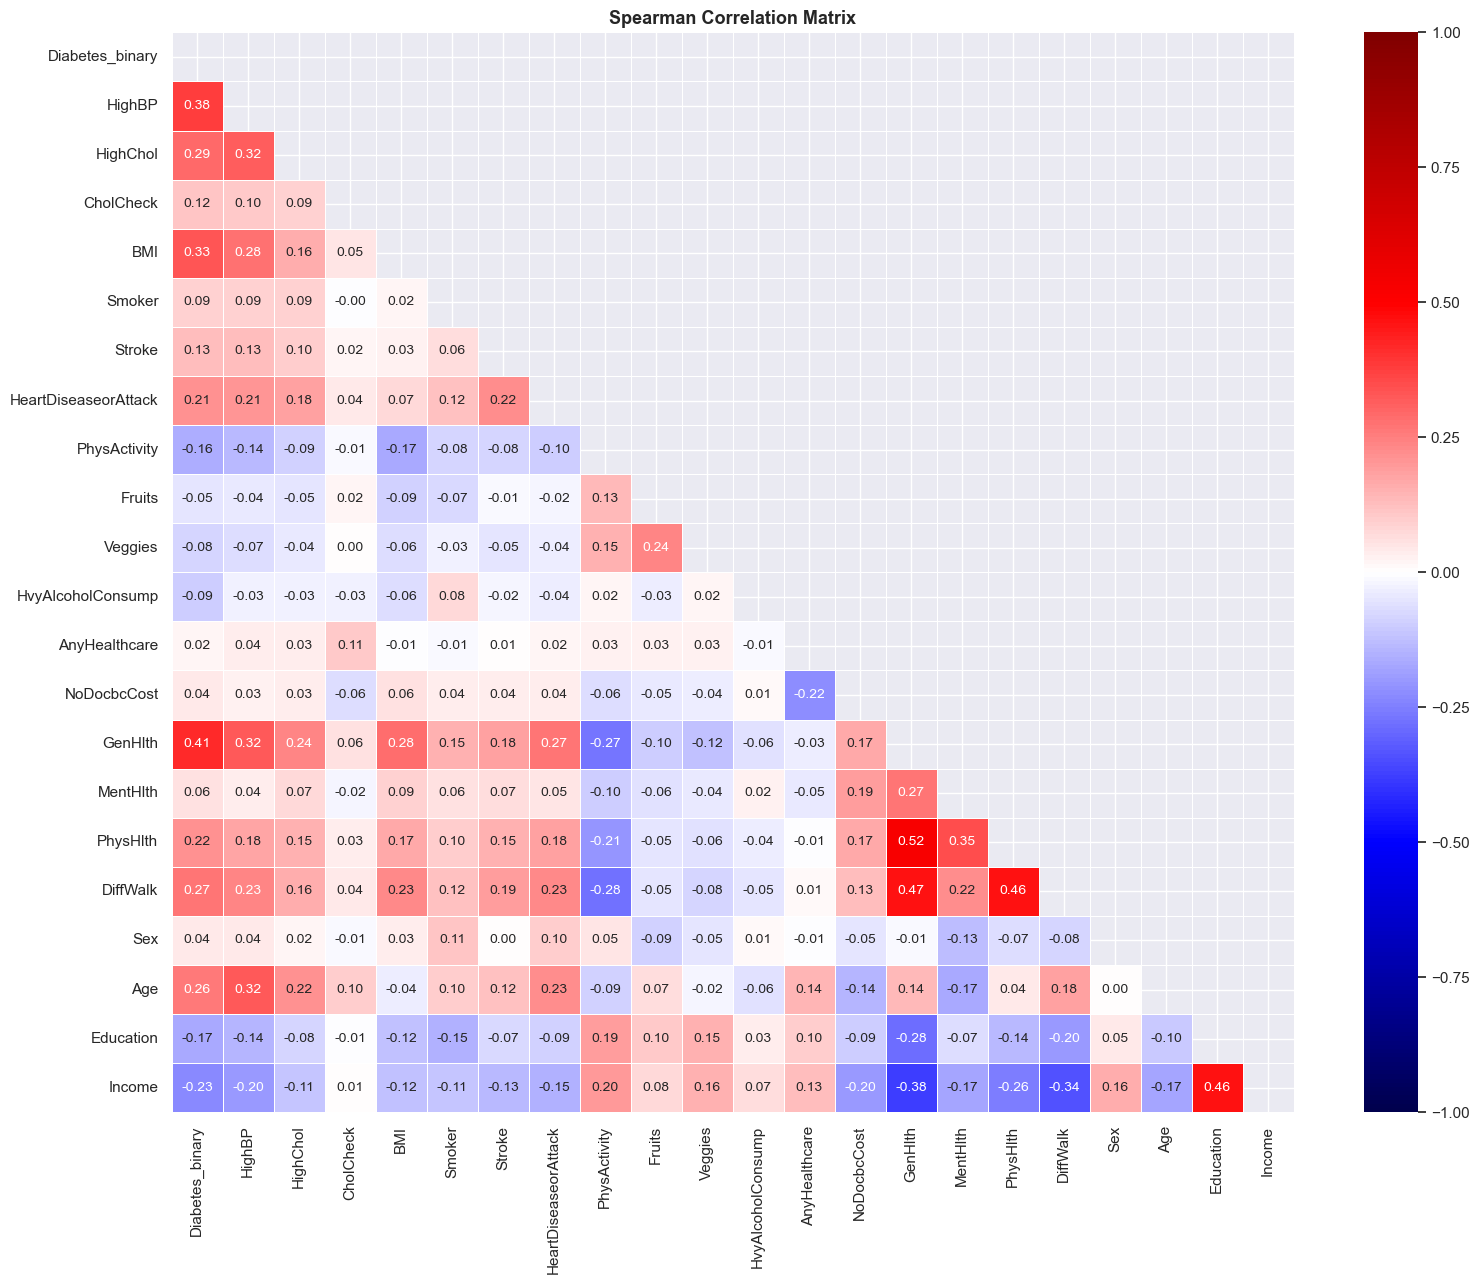

In [23]:
fig, ax = plt.subplots(figsize=(16, 13))

corr_matrix = df_5050_copy.corr(method='spearman')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   #only inferior matrix triangle
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',  #with values, 2 decimals
    cmap='seismic', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 10}
)
ax.set_title('Spearman Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()